Index(['customer_id', 'age', 'gender', 'income_bracket', 'loyalty_program',
       'membership_years', 'churned', 'marital_status', 'number_of_children',
       'education_level', 'occupation', 'transaction_id', 'transaction_date',
       'product_id', 'product_category', 'quantity', 'unit_price',
       'discount_applied', 'payment_method', 'store_location',
       'transaction_hour', 'day_of_week', 'week_of_year', 'month_of_year',
       'avg_purchase_value', 'purchase_frequency', 'last_purchase_date',
       'avg_discount_used', 'preferred_store', 'online_purchases',
       'in_store_purchases', 'avg_items_per_transaction',
       'avg_transaction_value', 'total_returned_items', 'total_returned_value',
       'total_sales', 'total_transactions', 'total_items_purchased',
       'total_discounts_received', 'avg_spent_per_category',
       'max_single_purchase_value', 'min_single_purchase_value',
       'product_name', 'product_brand', 'product_rating',
       'product_review_count', '

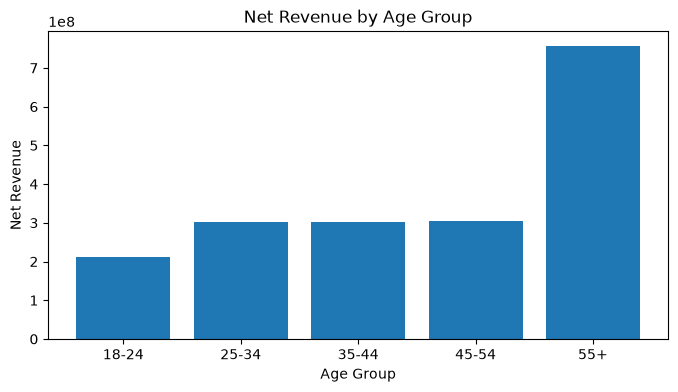

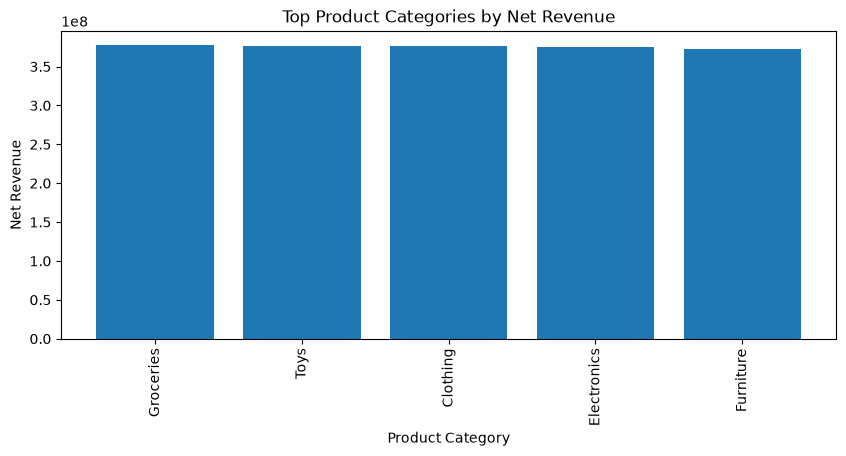

  recency_segment  customers       revenue
0  Active (0-30d)      84773  1.588440e+08
1   Warm (31-90d)     164478  3.086255e+08
2  At risk (90d+)     750749  1.410841e+09


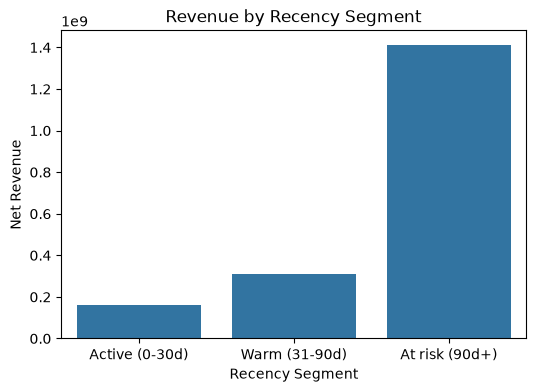

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("retail_data.csv")

# Basic checks
print(df.columns)
print("Shape:", df.shape)
print(df.dtypes)
print(df.isna().sum().sort_values(ascending=False).head(10))
print("Duplicate rows:", df.duplicated().sum())

# Convert numeric columns
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce").fillna(0)
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce").fillna(0)
df["discount_applied"] = pd.to_numeric(df["discount_applied"], errors="coerce").fillna(0)
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# Revenue calculation
df["line_revenue"] = df["quantity"] * df["unit_price"]
df["line_revenue_net"] = df["line_revenue"] * (1 - df["discount_applied"])

# Create age groups
bins = [0, 24, 34, 44, 54, 120]
labels = ["18-24", "25-34", "35-44", "45-54", "55+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    right=True
)

# Age group analysis
age_summary = (
    df.groupby("age_group", observed=False)
      .agg(
          revenue=("line_revenue_net", "sum"),
          units=("quantity", "sum"),
          transactions=("transaction_id", "nunique"),
          avg_order_value=("line_revenue_net", "mean")
      )
      .reset_index()
)

print(age_summary)

# Revenue by age group
plt.figure(figsize=(8,4))
plt.bar(age_summary["age_group"].astype(str), age_summary["revenue"])
plt.title("Net Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Net Revenue")
plt.show()

#product sorting by revenue
prod = (df.groupby("product_category")
          .agg(
              revenue=("line_revenue_net","sum"),
              units=("quantity","sum"),
          )
          .reset_index())


#a chart of the most valued products
top_prod = prod.sort_values("revenue", ascending=False).head(20)

plt.figure(figsize=(10,4))
plt.bar(top_prod["product_category"], top_prod["revenue"])
plt.title("Top Product Categories by Net Revenue")
plt.xlabel("Product Category")
plt.ylabel("Net Revenue")
plt.xticks(rotation=90)
plt.show()

#recent transansactions sorting and representation
df["recency_segment"] = pd.cut(
    df["days_since_last_purchase"],
    bins=[-1, 30, 90, df["days_since_last_purchase"].max() + 1],
    labels=["Active (0-30d)", "Warm (31-90d)", "At risk (90d+)"]
)
#Segment summary of customers and revenue
seg = (df.groupby("recency_segment")
         .agg(
             customers=("customer_id","nunique"),
             revenue=("line_revenue_net","sum")
         )
         .reset_index()
      )

print(seg)

#a plot of the segmented revenue
import seaborn as sns
plt.figure(figsize=(6,4))
sns.barplot(data=seg, x="recency_segment", y="revenue")
plt.title("Revenue by Recency Segment")
plt.xlabel("Recency Segment")
plt.ylabel("Net Revenue")
plt.show()


In [ ]:
#Step 4: 
#Dashboard

import pandas as pd
import numpy as np

import plotly.express as px
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

# ---------- Load & prepare ----------
df = pd.read_csv("retail_data.csv")

# Basic cleaning 
df = df.copy()
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce").fillna(0)
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce").fillna(0)
df["discount_applied"] = pd.to_numeric(df["discount_applied"], errors="coerce").fillna(0)
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# Revenue
df["line_revenue"] = df["quantity"] * df["unit_price"]

#discount scaling
df["line_revenue_net"] = df["line_revenue"] * (1 - df["discount_applied"])


#age group sorting 
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 24, 34, 44, 54, 100],
    labels=[
        "18-24",
        "25-34",
        "35-44",
        "45-54",
        "55+"
    ]
)
# Customer level
cust = (
    df.groupby("age_group")
      .agg(
          revenue=("line_revenue_net", "sum"),
          orders=("transaction_id", "nunique"),
          avg_recency=("days_since_last_purchase", "mean"),
          avg_membership=("membership_years", "mean")
      )
      .reset_index()
)
# Product level
prod = (
    df.groupby("product_category")
      .agg(
          revenue=("line_revenue_net", "sum"),
          units=("quantity", "sum")
      )
      .reset_index()
)
# Recency segments
max_days = df["days_since_last_purchase"].max()
df["recency_segment"] = pd.cut(
    df["days_since_last_purchase"],
    bins=[-1, 30, 90, max_days + 1],
    labels=["Active (0-30d)", "Warm (31-90d)", "At risk (90d+)"]
)

seg = (df.groupby("recency_segment")
         .agg(
             customers=("customer_id", "nunique"),
             revenue=("line_revenue_net", "sum")
         )
         .reset_index())

# ---------- Build dashboard ----------
app = dash.Dash(__name__)
app.title = "Retail Insights Dashboard"

# Controls
rev_max = float(cust["revenue"].max())
rev_min = float(cust["revenue"].min())

app.layout = html.Div([
    html.H2("Retail Financial Insights (Interactive)"),

    html.Div([
        html.Div([
            html.Label("Customer revenue threshold"),
            dcc.Slider(
                id="rev-threshold",
                min=0,
                max=rev_max,
                step=max(rev_max/200, 0.01),
                value=0
            ),
        ], style={"width": "45%", "display": "inline-block", "padding": "10px"}),

        html.Div([
            html.Label("Top N Age Groups / Product Categories"),
            dcc.Slider(
                id="top-n",
                min=5,
                max=50,
                step=5,
                value=20
            ),
        ], style={"width": "45%", "display": "inline-block", "padding": "10px"}),
    ]),

    html.Div([
        html.Div([
            dcc.Graph(id="kpi-total-revenue"),
        ], style={"width": "48%", "display": "inline-block"}),

        html.Div([
            dcc.Graph(id="kpi-orders"),
        ], style={"width": "48%", "display": "inline-block"}),
    ]),

    html.Div([
        html.Div([
            dcc.Graph(id="chart-top-customers"),
        ], style={"width": "50%", "display": "inline-block"}),

        html.Div([
            dcc.Graph(id="chart-top-products"),
        ], style={"width": "50%", "display": "inline-block"}),
    ]),

    html.Div([
        html.Div([
            dcc.Graph(id="chart-revenue-recency-segment"),
        ], style={"width": "100%"}),

        html.Div([
            dcc.Graph(id="chart-revenue-vs-orders"),
        ], style={"width": "100%"}),
    ]),

    html.Div([
        html.P(
            "Business Insight: Identify the age groups generating the most revenue, "
            "the product categories contributing the highest sales, and how revenue "
            "is distributed across customer recency segments."
         )
    ], style={"padding": "10px"})
])


@app.callback(
    Output("kpi-total-revenue", "figure"),
    Output("kpi-orders", "figure"),
    Output("chart-top-customers", "figure"),
    Output("chart-top-products", "figure"),
    Output("chart-revenue-recency-segment", "figure"),
    Output("chart-revenue-vs-orders", "figure"),
    Input("rev-threshold", "value"),
    Input("top-n", "value")
)
def update_dashboard(threshold, top_n):
    # Filter customers by revenue threshold
    cust_f = cust[cust["revenue"] >= threshold].copy()

    total_revenue = cust_f["revenue"].sum()
    total_orders = cust_f["orders"].sum()

    # KPI: total revenue
    fig_rev = px.pie(
        names=["Total net revenue"],
        values=[total_revenue],
        title="Total Net Revenue (filtered)"
    )

    # KPI: orders
    fig_ord = px.pie(
        names=["Total orders"],
        values=[total_orders],
        title="Total Orders (filtered)"
    )

    # Top customers bar
    top_c = cust_f.sort_values("revenue", ascending=False).head(int(top_n))
    fig_top_c = px.bar(
        top_c,
        x="age_group",
        y="revenue",
        title="Revenue by Age Group",
        labels={
          "age_group": "Age Group",
          "revenue": "Net Revenue"
         }
    )
    fig_top_c.update_layout(xaxis_tickangle=-45)

    # Top products bar (no filtering)
    top_p = prod.sort_values("revenue", ascending=False).head(int(top_n))
    fig_top_p = px.bar(
         top_p,
         x="product_category",
         y="revenue",
         title="Revenue by Product Category",
         labels={
             "product_category": "Product Category",
             "revenue": "Net Revenue"
        }
     )
    fig_top_p.update_layout(xaxis_tickangle=-45)

    # Revenue by recency 
    seg_sorted = seg.copy()
    fig_seg = px.bar(
        seg_sorted,
        x="recency_segment",
        y="revenue",
        title="Net Revenue by Recency Segment",
        labels={"recency_segment": "Recency Segment", "revenue": "Net Revenue"}
    )

    # Revenue vs Orders scatter (business concentration)
    fig_scatter = px.scatter(
        cust_f,
        x="orders",
        y="revenue",
        hover_data=["age_group", "avg_membership", "avg_recency"],
        title="Age Groups: Orders vs Net Revenue"
    )
    
    return fig_rev, fig_ord, fig_top_c, fig_top_p, fig_seg, fig_scatter


if __name__ == "__main__":
    app.run(debug=True)